In [1]:
#Importar librerias 
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix


In [2]:
#descargar el dataset
path = kagglehub.dataset_download("aryan208/financial-transactions-dataset-for-fraud-detection")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\pirom\.cache\kagglehub\datasets\aryan208\financial-transactions-dataset-for-fraud-detection\versions\1


In [3]:
#leer el dataset
df=pd.read_csv(f'{path}\\financial_fraud_detection_dataset.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

In [5]:
df.sample(5)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
2287288,T2387288,2023-01-12T21:54:45.055613,ACC522353,ACC142881,210.47,withdrawal,entertainment,London,pos,False,NaN,-3915.564044,2.05,16,0.41,UPI,238.117.47.130,D2753982
657378,T757378,2023-09-15T21:32:18.811070,ACC515906,ACC212672,776.73,withdrawal,online,Tokyo,atm,False,NaN,2227.857953,-1.44,18,0.57,ACH,93.133.62.177,D3034709
618627,T718627,2023-11-20T00:41:35.186858,ACC744922,ACC196491,28.36,transfer,travel,London,pos,False,NaN,4672.572566,0.39,10,0.91,ACH,241.78.44.213,D1053980
2429167,T2529167,2023-04-13T04:09:04.061594,ACC367885,ACC301955,47.22,withdrawal,travel,Tokyo,mobile,False,NaN,-4983.654343,-0.67,12,0.65,wire_transfer,177.21.15.34,D4557434
2580185,T2680185,2023-03-16T10:30:25.229335,ACC976073,ACC938328,23.56,transfer,restaurant,New York,mobile,False,NaN,-791.671497,1.47,18,0.27,card,2.223.122.201,D4914727


In [6]:
df.isnull().sum()

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64

In [7]:
#verificar datos de fraude_type
df['fraud_type'].unique()

array([nan, 'card_not_present'], dtype=object)

In [8]:
#rellenar datos de fraude_type
df['fraud_type']=df['fraud_type'].fillna(0)
df['fraud_type'].unique()

array([0, 'card_not_present'], dtype=object)

In [9]:
df.duplicated().sum()

0

In [10]:
#cambiar de tipo object a datetime
df['timestamp']=pd.to_datetime(df['timestamp'], format='ISO8601')

In [11]:
#crear nuevas columnas basadas en timestamp
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['weekday'] = df['timestamp'].dt.weekday
df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 else 0)

In [12]:
#Features por usuario
df['tx_count_sender'] = df.groupby('sender_account')['amount'].transform('count')

df['avg_amount_sender'] = df.groupby('sender_account')['amount'].transform('mean')

df['std_amount_sender'] = df.groupby('sender_account')['amount'].transform('std')

In [13]:
#Anomalía real
df['amount_zscore'] = (
    df['amount'] - df['avg_amount_sender']
) / (df['std_amount_sender'] + 1e-5)

In [14]:
#Frecuencia reciente
df = df.sort_values(['sender_account', 'timestamp'])

df['tx_last_1h'] = df.groupby('sender_account')['timestamp'].transform(
    lambda x: x.diff().dt.total_seconds().fillna(0)
)

In [15]:
#Dispositivo sospechoso
df['device_tx_count'] = df.groupby('device_hash')['amount'].transform('count')

In [16]:
#eliminar columnas no importantes
df= df.drop([
    'transaction_id',
    'sender_account',
    'fraud_type',
    'ip_address',
    'device_hash',
    'receiver_account'
], axis=1, errors='ignore')

In [17]:
#se agrupa en base al tipo de transaccion para observar si hay una tendencia
df_gb_transaction_type=df.groupby('transaction_type')['is_fraud'].sum().reset_index()
df_gb_transaction_type

,transaction_type,is_fraud
0,deposit,44786
1,payment,44565
2,transfer,45328
3,withdrawal,44874


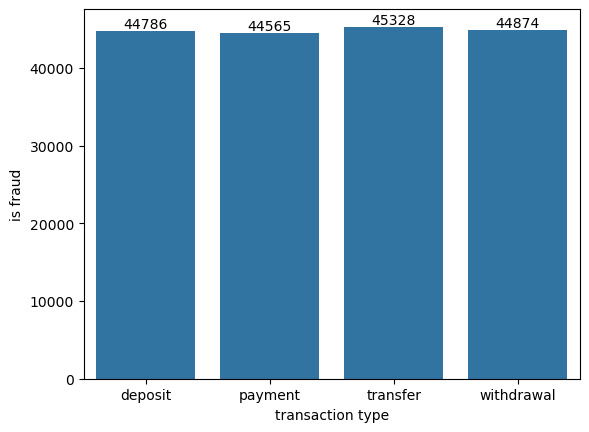

In [18]:
#se grafica
ax = sns.barplot(x="transaction_type", y="is_fraud", data=df_gb_transaction_type)
ax.bar_label(ax.containers[0], fontsize=10);
ax.set(xlabel='transaction type', ylabel='is fraud')
plt.show()

se observa que la cantidad de transacciones fraude es muy similar entre los distintos tipos de este, por lo que este no es un factor determinante para determinar si sera fraude o no

In [20]:
#se verifica el promedio de fraude segun el tipo de transaccion
fraud_rate = df.groupby('transaction_type')['is_fraud'].mean().reset_index()
fraud_rate

,transaction_type,is_fraud
0,deposit,0.035812
1,payment,0.035640
2,transfer,0.036253
3,withdrawal,0.035938


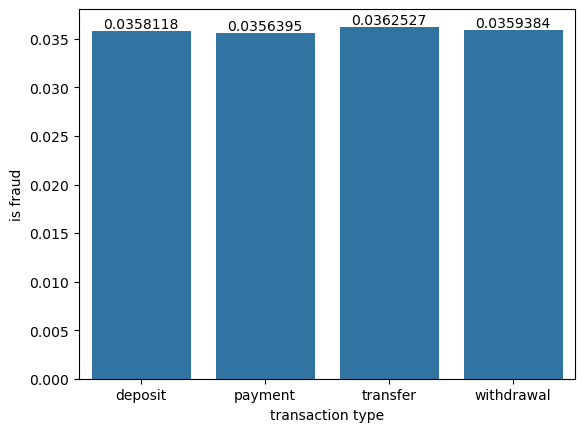

In [21]:
#se grafica
ax = sns.barplot(x="transaction_type", y="is_fraud", data=fraud_rate)
ax.bar_label(ax.containers[0], fontsize=10);
ax.set(xlabel='transaction type', ylabel='is fraud')
plt.show()

como se puede observar la tasa de fraude segun el tipo de transaccion no supera el 3.7%, lo cual es una cifra preocupante, puesto que una cifra sana rondaria el 0.1% 

In [23]:
#se agrupa en base al tipo de dispositivo usado para observar si hay una tendencia
df_gb_device_used=df.groupby('device_used')['is_fraud'].sum().reset_index()
df_gb_device_used

,device_used,is_fraud
0,atm,45217
1,mobile,44677
2,pos,44852
3,web,44807


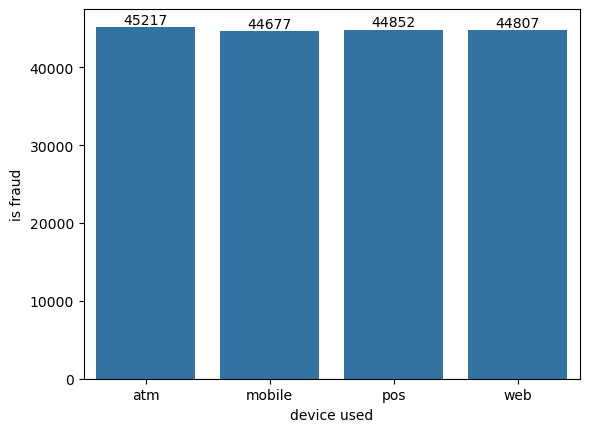

In [24]:
#se grafica
ax = sns.barplot(x="device_used", y="is_fraud", data=df_gb_device_used)
ax.bar_label(ax.containers[0], fontsize=10);
ax.set(xlabel='device used', ylabel='is fraud')
plt.show()

se observa que la cantidad de transacciones fraude es muy similar entre los distintos tipo de dispositivos usados, por lo que este no es un factor determinante para determinar si sera fraude o no

In [26]:
 #se agrupa en base al tipo de mercancia usado para observar si hay una tendencia
df_gb_merchant_category=df.groupby('merchant_category')['is_fraud'].sum().reset_index()
df_gb_merchant_category

,merchant_category,is_fraud
0,entertainment,22573
1,grocery,22516
2,online,22324
3,other,22556
4,restaurant,22367
5,retail,22453
6,travel,22503
7,utilities,22261


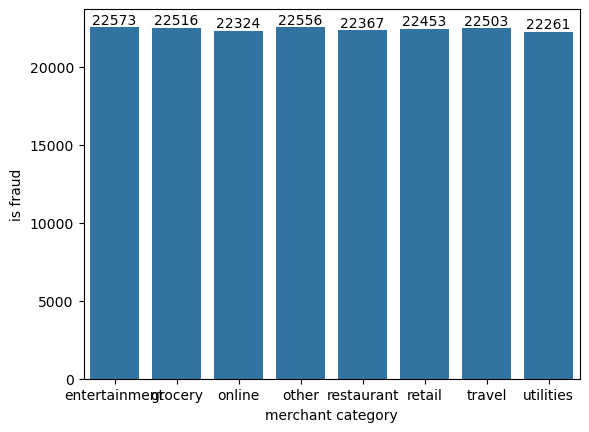

In [27]:
#se grafica
ax = sns.barplot(x="merchant_category", y="is_fraud", data=df_gb_merchant_category)
ax.bar_label(ax.containers[0], fontsize=10);
ax.set(xlabel='merchant category', ylabel='is fraud')
plt.show()

In [28]:
#se agrupa en base al mes para observar si hay una tendencia
df_gb_month=df.groupby('month')['is_fraud'].sum().reset_index()
df_gb_month

,month,is_fraud
0,1,14981
1,2,13777
2,3,15247
3,4,14761
4,5,15133
5,6,14759
6,7,15395
7,8,15208
8,9,14855
9,10,15331


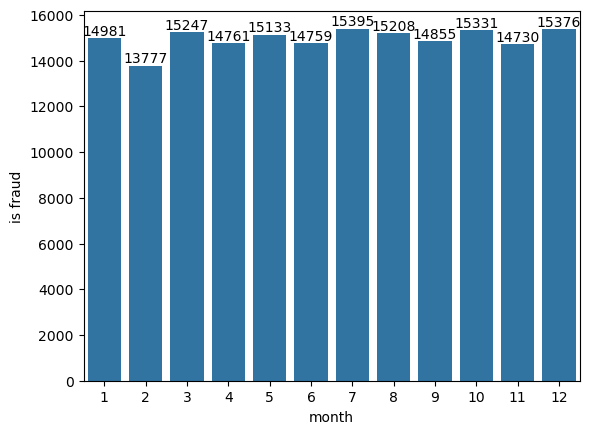

In [29]:
#se grafica
ax = sns.barplot(x="month", y="is_fraud", data=df_gb_month)
ax.bar_label(ax.containers[0], fontsize=10);
ax.set(xlabel='month', ylabel='is fraud')
plt.show()

In [30]:
#se agrupa en base a la hora para observar si hay una tendencia
df_gb_hour=df.groupby('hour')['is_fraud'].sum().reset_index()
df_gb_hour

,hour,is_fraud
0,0,7572
1,1,7462
2,2,7385
3,3,7497
4,4,7559
5,5,7580
6,6,7512
7,7,7515
8,8,7627
9,9,7428


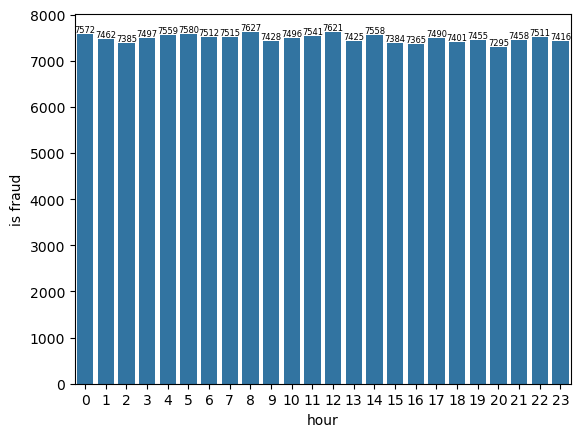

In [31]:
#se grafica
ax = sns.barplot(x="hour", y="is_fraud", data=df_gb_hour)
ax.bar_label(ax.containers[0], fontsize=6);
ax.set(xlabel='hour', ylabel='is fraud')
plt.show()

<Axes: >

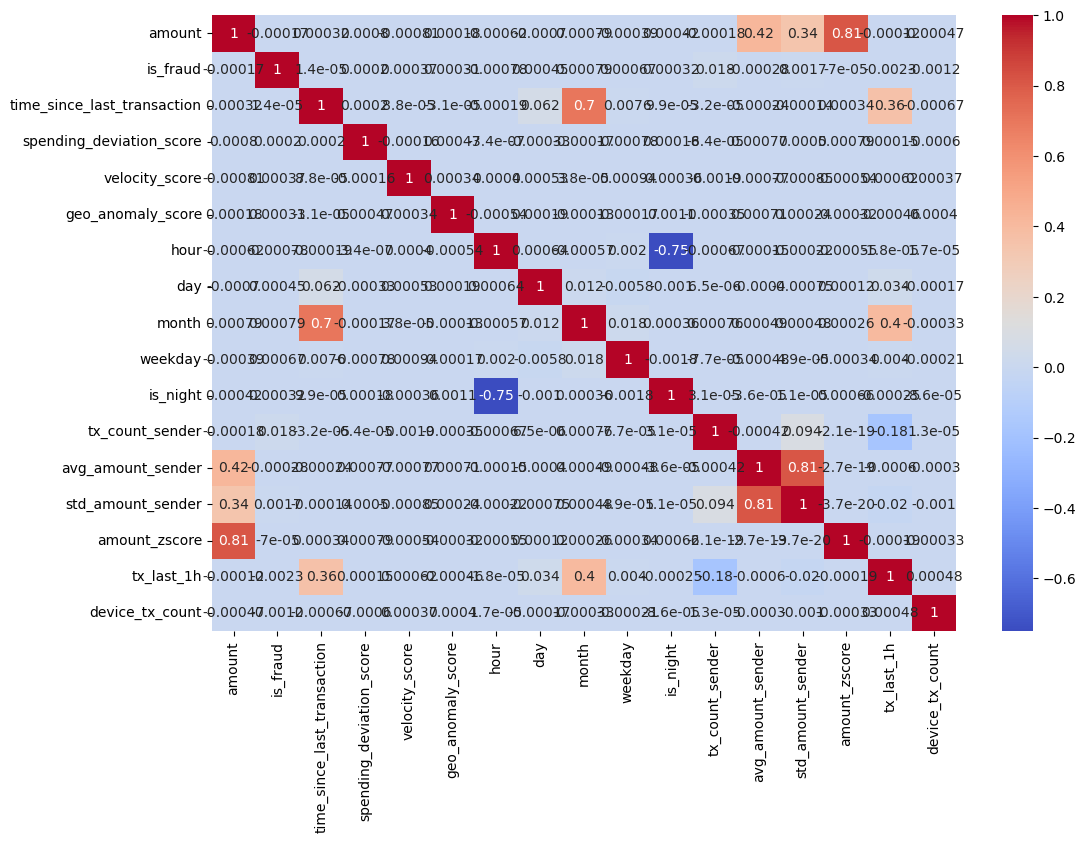

In [32]:
#Analisis de correlacion
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [33]:
df_sample = df.sample(100000, random_state=42)

In [34]:
X = df_sample.drop(['is_fraud'], axis=1)
y = df_sample['is_fraud']

In [49]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# Columnas numéricas
num_cols = df_sample.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Columnas categóricas
cat_cols = df_sample.select_dtypes(include=['object', 'category']).columns.tolist()

# Transformador numérico
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Transformador categórico
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Pipeline completo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,stratify=y, test_size=0.25, random_state=42)

In [53]:
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [5, 10],
    'model__max_features': ['sqrt']
}

In [55]:
CV_rfc = RandomizedSearchCV(estimator=pipeline, 
                                    param_distributions=param_grid, 
                                    n_iter=10,
                                    cv=5,
                                    scoring='recall',
                                    n_jobs=-1,
                                    verbose=3,
                                    random_state=42)
CV_rfc.fit(X_train, y_train)

C:\Users\pirom\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\pirom\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\pirom\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\pirom\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pirom\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\pirom\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['amount',
                                                                                'time_since_last_transaction',
                                                                                'spending_deviation_score',
                                                                                'velocity_score',
                                                                                'geo_anomaly_score',
                                                                                'is_night',
                                                                                'tx_count_sender',
                                                                                'avg_amount_sender',
                                                                                'std_amount_sender',
                                                                                'amount_z...
                                                                                'merchant_category',
                                                                                'location',
                                                                                'device_used',
                                                                                'payment_channel'])])),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     max_depth=10,
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10],
                                        'model__max_features': ['sqrt'],
                                        'model__n_estimators': [50, 100]},
                   random_state=42, scoring='recall', verbose=3)

In [56]:
import joblib

joblib.dump(CV_rfc.best_estimator_, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [57]:
model = joblib.load('random_forest_model.pkl')

In [58]:
y_pred_rfc = model.predict(X_test)
accuracy_score(y_test, y_pred_rfc)

0.96376

In [59]:
y_probs = model.predict_proba(X_test)[:,1]

y_pred_02 = (y_probs > 0.2).astype(int)
y_pred_01 = (y_probs > 0.1).astype(int)
y_pred_005 = (y_probs > 0.05).astype(int)

In [60]:

print("Threshold 0.2")
print(classification_report(y_test, y_pred_02))

print("Threshold 0.1")
print(classification_report(y_test, y_pred_01))

print("Threshold 0.05")
print(classification_report(y_test, y_pred_005))

Threshold 0.2
              precision    recall  f1-score   support

       False       0.96      0.03      0.05     24094
        True       0.04      0.97      0.07       906

    accuracy                           0.06     25000
   macro avg       0.50      0.50      0.06     25000
weighted avg       0.93      0.06      0.05     25000

Threshold 0.1
              precision    recall  f1-score   support

       False       0.00      0.00      0.00     24094
        True       0.04      1.00      0.07       906

    accuracy                           0.04     25000
   macro avg       0.02      0.50      0.03     25000
weighted avg       0.00      0.04      0.00     25000

Threshold 0.05
              precision    recall  f1-score   support

       False       0.00      0.00      0.00     24094
        True       0.04      1.00      0.07       906

    accuracy                           0.04     25000
   macro avg       0.02      0.50      0.03     25000
weighted avg       0.00      0.

C:\Users\pirom\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pirom\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pirom\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pirom\anaconda3\Lib\site-packages\sklearn\metr

In [62]:
print(classification_report(y_test, y_pred_rfc))

C:\Users\pirom\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       False       0.96      1.00      0.98     24094
        True       0.00      0.00      0.00       906

    accuracy                           0.96     25000
   macro avg       0.48      0.50      0.49     25000
weighted avg       0.93      0.96      0.95     25000



C:\Users\pirom\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\pirom\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [63]:
roc_auc_score(y_test, y_probs)

0.5008126055583255

In [64]:
cm = confusion_matrix(y_test, y_pred_rfc)
cm

array([[24094,     0],
       [  906,     0]], dtype=int64)